# Fine-Tuned MobileNetV2


In [1]:
import os

USE_GPU = False
if USE_GPU:
    os.environ.pop('CUDA_VISIBLE_DEVICES', None)
    os.environ['DML_VISIBLE_DEVICES'] = '0'
else:
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

from pathlib import Path
import re
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATASET_VAL_SPLIT = 0.2
GROUP_CHUNK_SIZE = 20
WEBCAM_TUNE_SPLIT = 0.7
WEBCAM_TUNE_TRAIN_SPLIT = 0.8
WEBCAM_BOOST = 3
AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    if not USE_GPU:
        tf.config.set_visible_devices([], 'GPU')
except Exception as error:
    print('Device visibility already initialized:', error)

print('TensorFlow:', tf.__version__)
print('USE_GPU:', USE_GPU)
print('Visible GPUs:', tf.config.get_visible_devices('GPU'))


TensorFlow: 2.10.0
USE_GPU: False
Visible GPUs: []


In [ ]:
def find_project_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path('C:/Users/user/Documents/GitHub/behavior-detection/CVProject'),
        Path('C:/Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk/CVProject'),
    ]
    for c in candidates:
        if (c / 'Code').exists() and (c / 'Dataset').exists() and (c / 'ValidationSet').exists():
            return c.resolve()
    raise FileNotFoundError('Could not locate project root with Code/, Dataset/, ValidationSet/.')


def natural_key(path: Path):
    parts = re.split(r'(\d+)', path.stem)
    return [int(p) if p.isdigit() else p.lower() for p in parts]


def extract_group_key(path: Path) -> str:
    m = re.search(r'(\d+)$', path.stem)
    chunk_id = int(m.group(1)) // GROUP_CHUNK_SIZE if m else 0
    prefix = re.sub(r'[_-]?\d+$', '', path.stem)
    return f'{path.parent.name}::{prefix}::chunk_{chunk_id:04d}'


def build_sequence_split_lists(dataset_root: Path, class_names, val_split: float = DATASET_VAL_SPLIT):
    train_paths, train_labels, val_paths, val_labels = [], [], [], []
    split_summary = []

    for class_idx, class_name in enumerate(class_names):
        class_dir = dataset_root / class_name
        class_files = sorted([p for p in class_dir.iterdir() if p.is_file()], key=natural_key)

        grouped = {}
        for fp in class_files:
            grouped.setdefault(extract_group_key(fp), []).append(str(fp))

        ordered = sorted(grouped.items(), key=lambda x: x[0])
        val_group_count = max(1, int(round(len(ordered) * val_split)))
        val_group_keys = {k for k, _ in ordered[-val_group_count:]}

        class_train = class_val = 0
        for gk, paths in ordered:
            if gk in val_group_keys:
                val_paths.extend(paths)
                val_labels.extend([class_idx] * len(paths))
                class_val += len(paths)
            else:
                train_paths.extend(paths)
                train_labels.extend([class_idx] * len(paths))
                class_train += len(paths)

        split_summary.append({'class_name': class_name, 'groups': len(ordered), 'train_images': class_train, 'val_images': class_val})

    return train_paths, train_labels, val_paths, val_labels, split_summary


def load_folder_paths_labels(root: Path, class_names):
    paths, labels = [], []
    counts = {}
    for i, cname in enumerate(class_names):
        files = sorted([p for p in (root / cname).glob('*.jpg') if p.is_file()], key=natural_key)
        counts[cname] = len(files)
        paths.extend([str(p) for p in files])
        labels.extend([i] * len(files))
    return paths, labels, counts


def stratified_split(paths, labels, train_fraction, seed=SEED):
    rng = np.random.default_rng(seed)
    paths = np.array(paths)
    labels = np.array(labels)

    tr_idx, te_idx = [], []
    for label in np.unique(labels):
        idx = np.where(labels == label)[0]
        rng.shuffle(idx)
        cut = max(1, int(round(len(idx) * train_fraction)))
        cut = min(cut, len(idx) - 1) if len(idx) > 1 else len(idx)
        tr_idx.extend(idx[:cut].tolist())
        te_idx.extend(idx[cut:].tolist())

    tr_idx = np.array(tr_idx, dtype=int)
    te_idx = np.array(te_idx, dtype=int)
    return paths[tr_idx].tolist(), labels[tr_idx].tolist(), paths[te_idx].tolist(), labels[te_idx].tolist()


def decode_and_resize(path, label, training=False):
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    if training:
        image = tf.image.random_brightness(image, max_delta=0.08)
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label


def make_dataset(paths, labels, training=False):
    p = np.array(paths)
    y = np.array(labels, dtype=np.int32)
    if training and len(p) > 0:
        rng = np.random.default_rng(SEED)
        idx = rng.permutation(len(p))
        p = p[idx]
        y = y[idx]
    ds = tf.data.Dataset.from_tensor_slices((p, y))
    ds = ds.map(lambda a, b: decode_and_resize(a, b, training=training), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


def build_model(num_classes, base_trainable=False):
    base_model = keras.applications.MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
    base_model.trainable = base_trainable

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(2e-4))(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs), base_model


def evaluate_on_dataset(model, ds, y_true, class_names, title_prefix='Evaluation', cmap='Blues'):
    y_prob = model.predict(ds, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, cmap=cmap)
    plt.title(f'{title_prefix} Confusion Matrix')
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha='right')
    plt.yticks(ticks, class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > threshold else 'black')
    plt.tight_layout()

    print(f'{title_prefix} Accuracy: {acc:.4f}')
    print(f'{title_prefix} Macro-F1: {macro_f1:.4f}')
    print(f'{title_prefix} Weighted-F1: {weighted_f1:.4f}')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

    return {'accuracy': acc, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1, 'y_pred': y_pred}


In [3]:
PROJECT_ROOT = find_project_root()
DATASET_ROOT = PROJECT_ROOT / 'Dataset'
VALIDATION_ROOT = PROJECT_ROOT / 'ValidationSet'
BEST_FINE_TUNE_PATH = PROJECT_ROOT / 'Code' / 'best_final_proctor_model_finetune.h5'
MODEL_OUTPUT_PATH = PROJECT_ROOT / 'Code' / 'final_proctor_model.h5'

dataset_classes = sorted([p.name for p in DATASET_ROOT.iterdir() if p.is_dir()])
validation_classes = sorted([p.name for p in VALIDATION_ROOT.iterdir() if p.is_dir()])

assert dataset_classes == validation_classes, f'Class mismatch: Dataset={dataset_classes}, ValidationSet={validation_classes}'

CLASS_NAMES = dataset_classes
NUM_CLASSES = len(CLASS_NAMES)

print('Project root:', PROJECT_ROOT)
print('Classes:', CLASS_NAMES)
print('Num classes:', NUM_CLASSES)

train_paths, train_labels, val_paths, val_labels, split_summary = build_sequence_split_lists(DATASET_ROOT, CLASS_NAMES)
print()
print('Main dataset split summary:')
for row in split_summary:
    print(row)

webcam_paths_all, webcam_labels_all, webcam_counts = load_folder_paths_labels(VALIDATION_ROOT, CLASS_NAMES)
print()
print('ValidationSet counts:')
for k, v in webcam_counts.items():
    print(f'{k}: {v}')

if min(webcam_counts.values()) < 10:
    print()
    print('Warning: at least one class has <10 webcam samples; eval variance may be high.')

webcam_tune_paths, webcam_tune_labels, webcam_eval_paths, webcam_eval_labels = stratified_split(webcam_paths_all, webcam_labels_all, train_fraction=WEBCAM_TUNE_SPLIT, seed=SEED)
webcam_tune_train_paths, webcam_tune_train_labels, webcam_tune_val_paths, webcam_tune_val_labels = stratified_split(webcam_tune_paths, webcam_tune_labels, train_fraction=WEBCAM_TUNE_TRAIN_SPLIT, seed=SEED + 1)

print()
print('Webcam split sizes:')
print('webcam_tune_train:', len(webcam_tune_train_paths))
print('webcam_tune_val  :', len(webcam_tune_val_paths))
print('webcam_eval      :', len(webcam_eval_paths), '<- held-out final eval')

combined_train_paths = train_paths + (webcam_tune_train_paths * WEBCAM_BOOST)
combined_train_labels = train_labels + (webcam_tune_train_labels * WEBCAM_BOOST)

combined_train_ds = make_dataset(combined_train_paths, combined_train_labels, training=True)
webcam_tune_val_ds = make_dataset(webcam_tune_val_paths, webcam_tune_val_labels, training=False)
webcam_eval_ds = make_dataset(webcam_eval_paths, webcam_eval_labels, training=False)

class_counts = np.bincount(np.array(combined_train_labels), minlength=NUM_CLASSES)
max_count = np.max(class_counts)
class_weight = {i: float(np.clip(np.sqrt(max_count / max(class_counts[i], 1)), 0.8, 2.5)) for i in range(NUM_CLASSES)}

print()
print('Class counts (combined train):', class_counts.tolist())
print('Class weights:', class_weight)


Project root: C:\Users\user\Desktop\behavior-detection\DLProject
Classes: ['distracted', 'fatigue', 'focused', 'raise_hand', 'sleeping', 'using_smartphone', 'writing_reading']
Num classes: 7

Main dataset split summary:
{'class_name': 'distracted', 'groups': 80, 'train_images': 1181, 'val_images': 301}
{'class_name': 'fatigue', 'groups': 52, 'train_images': 714, 'val_images': 172}
{'class_name': 'focused', 'groups': 146, 'train_images': 2285, 'val_images': 573}
{'class_name': 'raise_hand', 'groups': 54, 'train_images': 683, 'val_images': 177}
{'class_name': 'sleeping', 'groups': 41, 'train_images': 637, 'val_images': 152}
{'class_name': 'using_smartphone', 'groups': 25, 'train_images': 348, 'val_images': 88}
{'class_name': 'writing_reading', 'groups': 65, 'train_images': 1015, 'val_images': 234}

ValidationSet counts:
distracted: 27
fatigue: 27
focused: 27
raise_hand: 24
sleeping: 20
using_smartphone: 26
writing_reading: 27

Webcam split sizes:
webcam_tune_train: 99
webcam_tune_val  : 

In [4]:
model, base_model = build_model(NUM_CLASSES, base_trainable=False)
model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 224, 224, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 224, 224, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                      

In [5]:
# Stage 1: Classification Head
base_model.trainable = False
model.compile(optimizer=keras.optimizers.Adam(learning_rate=2e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks_stage1 = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6, verbose=1),
]

history_stage1 = model.fit(
    combined_train_ds,
    validation_data=webcam_tune_val_ds,
    epochs=8,
    callbacks=callbacks_stage1,
    class_weight=class_weight,
)


Epoch 1/8
224/224 [==============================] - 76s 330ms/step - loss: 0.6525 - accuracy: 0.8721 - val_loss: 1.0545 - val_accuracy: 0.6923 - lr: 2.0000e-04
Epoch 2/8
224/224 [==============================] - 73s 324ms/step - loss: 0.1487 - accuracy: 0.9824 - val_loss: 0.6706 - val_accuracy: 0.7692 - lr: 2.0000e-04
Epoch 3/8
224/224 [==============================] - 70s 310ms/step - loss: 0.1057 - accuracy: 0.9881 - val_loss: 0.6614 - val_accuracy: 0.8077 - lr: 2.0000e-04
Epoch 4/8
224/224 [==============================] - 70s 312ms/step - loss: 0.0878 - accuracy: 0.9919 - val_loss: 0.6094 - val_accuracy: 0.8077 - lr: 2.0000e-04
Epoch 5/8
224/224 [==============================] - 75s 335ms/step - loss: 0.0746 - accuracy: 0.9947 - val_loss: 0.5433 - val_accuracy: 0.8077 - lr: 2.0000e-04
Epoch 6/8
224/224 [==============================] - ETA: 0s - loss: 0.0698 - accuracy: 0.9953
Epoch 6: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.
224/224 [===============

In [6]:
# Stage 2: Gentle Fine-Tune
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(learning_rate=8e-6), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks_stage2 = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(BEST_FINE_TUNE_PATH, monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=1),
]

history_stage2 = model.fit(
    combined_train_ds,
    validation_data=webcam_tune_val_ds,
    epochs=12,
    callbacks=callbacks_stage2,
    class_weight=class_weight,
)

try:
    model.load_weights(BEST_FINE_TUNE_PATH)
    print(f'Loaded best stage-2 weights from: {BEST_FINE_TUNE_PATH}')
except Exception as error:
    print('Could not load BEST_FINE_TUNE_PATH; using in-memory best weights:', error)


Epoch 1/12
224/224 [==============================] - ETA: 0s - loss: 0.0557 - accuracy: 0.9983
Epoch 1: val_loss improved from inf to 0.52886, saving model to C:\Users\user\Desktop\behavior-detection\DLProject\Code\best_final_proctor_model_finetune.h5
224/224 [==============================] - 92s 400ms/step - loss: 0.0557 - accuracy: 0.9983 - val_loss: 0.5289 - val_accuracy: 0.8846 - lr: 8.0000e-06
Epoch 2/12
224/224 [==============================] - ETA: 0s - loss: 0.0489 - accuracy: 0.9999
Epoch 2: val_loss improved from 0.52886 to 0.43056, saving model to C:\Users\user\Desktop\behavior-detection\DLProject\Code\best_final_proctor_model_finetune.h5
224/224 [==============================] - 90s 399ms/step - loss: 0.0489 - accuracy: 0.9999 - val_loss: 0.4306 - val_accuracy: 0.8846 - lr: 8.0000e-06
Epoch 3/12
224/224 [==============================] - ETA: 0s - loss: 0.0484 - accuracy: 0.9997
Epoch 3: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-06.

Epoch 3: val_lo

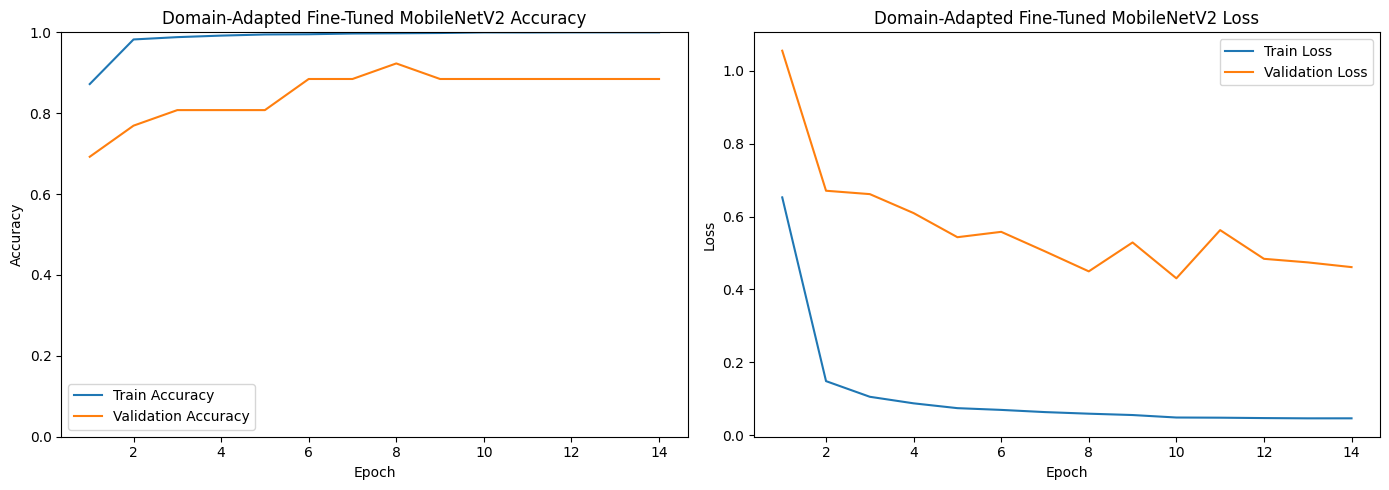

In [7]:
hist_acc = history_stage1.history['accuracy'] + history_stage2.history['accuracy']
hist_val_acc = history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']
hist_loss = history_stage1.history['loss'] + history_stage2.history['loss']
hist_val_loss = history_stage1.history['val_loss'] + history_stage2.history['val_loss']

epochs = range(1, len(hist_acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, hist_acc, label='Train Accuracy')
plt.plot(epochs, hist_val_acc, label='Validation Accuracy')
plt.title('Domain-Adapted Fine-Tuned MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, hist_loss, label='Train Loss')
plt.plot(epochs, hist_val_loss, label='Validation Loss')
plt.title('Domain-Adapted Fine-Tuned MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()


Domain-Adapted Fine-Tuned MobileNetV2 Accuracy: 0.9245
Domain-Adapted Fine-Tuned MobileNetV2 Macro-F1: 0.9258
Domain-Adapted Fine-Tuned MobileNetV2 Weighted-F1: 0.9259
                  precision    recall  f1-score   support

      distracted     1.0000    1.0000    1.0000         8
         fatigue     0.7000    0.8750    0.7778         8
         focused     1.0000    1.0000    1.0000         8
      raise_hand     0.8333    0.7143    0.7692         7
        sleeping     1.0000    1.0000    1.0000         6
using_smartphone     1.0000    0.8750    0.9333         8
 writing_reading     1.0000    1.0000    1.0000         8

        accuracy                         0.9245        53
       macro avg     0.9333    0.9235    0.9258        53
    weighted avg     0.9327    0.9245    0.9259        53



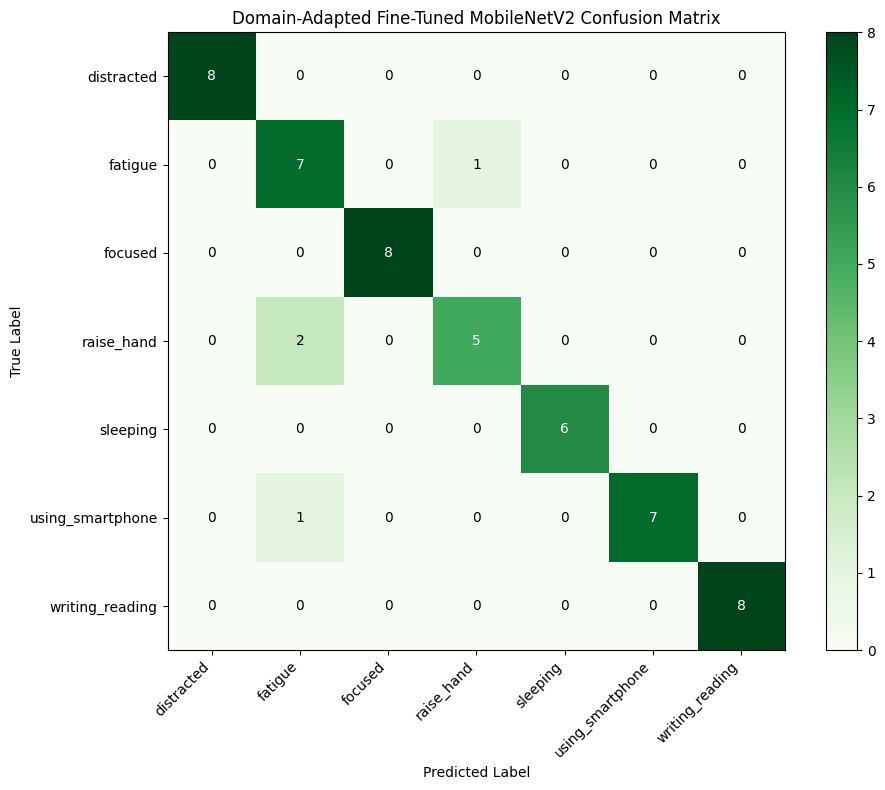

In [8]:
final_metrics = evaluate_on_dataset(
    model,
    webcam_eval_ds,
    np.array(webcam_eval_labels),
    CLASS_NAMES,
    title_prefix='Domain-Adapted Fine-Tuned MobileNetV2',
    cmap='Greens'
)


In [9]:
model.save(MODEL_OUTPUT_PATH)
print(f'Final model saved to: {MODEL_OUTPUT_PATH}')


Final model saved to: C:\Users\user\Desktop\behavior-detection\DLProject\Code\final_proctor_model.h5
